In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
%matplotlib inline

In [3]:
from google.colab import files
uploaded = files.upload()

Saving preprocessed_dataset.csv to preprocessed_dataset.csv


In [5]:
import pandas as pd
df = pd.read_csv("preprocessed_dataset.csv")
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,attack type
0,9.358975,-0.305021,-1.573795,-2.337903,2.164631,-0.448710,-0.095588,-0.999269,0.531986,1.180831,...,0.002886,-0.206970,0.061554,0.263916,0.498915,-0.060638,0.000622,-0.618587,0.151135,1
1,6.377827,-0.747452,4.507055,-0.135987,2.131633,0.543314,-0.148042,-3.242425,-0.612370,1.597544,...,1.214270,0.811346,0.428905,0.354355,0.425527,-0.047228,-0.002988,1.103984,-0.203426,1
2,-1.989040,-0.039763,0.196994,-0.669131,-1.244578,-0.916119,-0.069794,-0.626994,0.842700,-0.256847,...,0.035178,-0.006665,-0.042091,0.041809,0.021472,-0.001749,0.000467,-0.009116,-0.010473,0
3,9.316547,0.566182,1.136256,13.518495,-0.055885,-5.669852,-0.127834,-3.038099,-2.264454,2.124777,...,-0.267683,0.012553,0.412491,-0.305303,-0.732627,-0.001900,-0.001185,-0.498448,0.480757,0
4,-2.000448,-0.039795,0.208647,-0.598662,-1.022022,-0.650070,-0.050272,-0.544500,0.528242,-0.183290,...,-0.047342,-0.132341,-0.132318,0.199306,-0.069502,-0.001290,0.001431,-0.008187,-0.003693,0


In [6]:
# Encode labels
le = LabelEncoder()
df['attack type'] = le.fit_transform(df['attack type'])

In [7]:
# Split data
X = df.drop('attack type', axis=1)
y = df['attack type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [8]:
import tensorflow as tf
import numpy as np

# Build ANN
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    # Binary output
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [9]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [10]:
# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 0.8603 - auc: 0.9367 - loss: 0.3248 - precision: 0.8499 - recall: 0.8747 - val_accuracy: 0.9160 - val_auc: 0.9738 - val_loss: 0.3144 - val_precision: 0.8716 - val_recall: 0.9819
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9258 - auc: 0.9761 - loss: 0.1968 - precision: 0.9155 - recall: 0.9379 - val_accuracy: 0.9400 - val_auc: 0.9833 - val_loss: 0.2169 - val_precision: 0.9111 - val_recall: 0.9793
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9348 - auc: 0.9817 - loss: 0.1700 - precision: 0.9298 - recall: 0.9404 - val_accuracy: 0.9471 - val_auc: 0.9897 - val_loss: 0.1646 - val_precision: 0.9250 - val_recall: 0.9767
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9347 - auc: 0.9835 - loss: 0.1626 - precision: 0.9240 - recall: 0.9470 - val_accuracy: 0.9498 - val_auc: 0.9917 - val_loss: 0.1404 - val_precision: 0.9302 - val_recall: 0.9759
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━

In [18]:
# Predictions
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.9765333333333334
Precision: 0.9706652697747512
Recall   : 0.9830238726790451
F1 Score : 0.9768054823405377


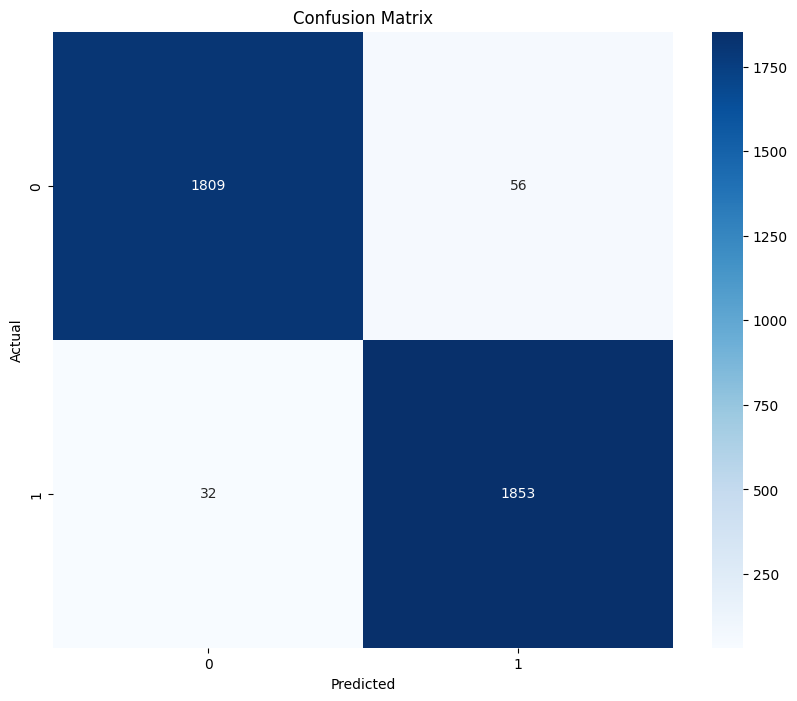

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()